## 1. Environment Setup

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report
)
import joblib

# XGBoost
import xgboost as xgb

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Paths
DATA_PATH = 'preprocessed_data/timestamped_predictive_maintenance_timeseries_synthetic.csv'
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Feature configuration
NUMERICAL_FEATURES = [
    'air_temperature_K',
    'process_temperature_K',
    'rotational_speed_rpm',
    'torque_Nm',
    'tool_wear_min'
]
CATEGORICAL_FEATURE = 'engine_type_encoded'
SEQUENCE_LENGTH = 50  # Timesteps per sequence

# AC-02 Performance Targets
TARGET_RECALL = 0.70
TARGET_ACCURACY = 0.70

print("✓ Environment configured")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Artifacts directory: {ARTIFACTS_DIR}")
print(f"  Sequence length: {SEQUENCE_LENGTH}")

✓ Environment configured
  Random seed: 42
  Artifacts directory: artifacts
  Sequence length: 50


## 2. Data Loading & Validation

In [2]:
# Load synthetic time-series dataset
df = pd.read_csv(DATA_PATH)

# Basic validation
print("Dataset Information:")
print(f"  Total samples: {len(df):,}")
print(f"  Unique machines: {df['product_id'].nunique():,}")
print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"  Columns: {list(df.columns)}")

# Check for required columns
required_cols = ['product_id', 'timestamp', 'is_failure', 'synthetic_RUL'] + NUMERICAL_FEATURES
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Encode categorical feature if needed
if 'engine_type' in df.columns and 'engine_type_encoded' not in df.columns:
    engine_encoder = LabelEncoder()
    df['engine_type_encoded'] = engine_encoder.fit_transform(df['engine_type'])
    joblib.dump(engine_encoder, ARTIFACTS_DIR / 'encoder_engine_type.joblib')

# Target distribution
failure_rate = df['is_failure'].mean()
print(f"\n  Failure rate: {failure_rate:.2%}")
print(f"  Healthy samples: {(~df['is_failure'].astype(bool)).sum():,}")
print(f"  Failure samples: {df['is_failure'].sum():,}")

# Validate per-machine time-series structure
machine_counts = df.groupby('product_id').size()
print(f"\n  Timesteps per machine:")
print(f"    Min: {machine_counts.min()}")
print(f"    Max: {machine_counts.max()}")
print(f"    Mean: {machine_counts.mean():.1f}")

print("\n✓ Data loaded and validated")

Dataset Information:
  Total samples: 700,209
  Unique machines: 10,000
  Date range: 2023-12-29 00:00:00 to 2024-04-30 18:00:00
  Columns: ['product_id', 'unit_id', 'timestamp', 'engine_type', 'air_temperature_K', 'process_temperature_K', 'rotational_speed_rpm', 'torque_Nm', 'tool_wear_min', 'failure_type', 'is_failure', 'synthetic_RUL', 'step_index']

  Failure rate: 0.17%
  Healthy samples: 699,007
  Failure samples: 1,202

  Timesteps per machine:
    Min: 60
    Max: 80
    Mean: 70.0

✓ Data loaded and validated


## 3. Essential EDA

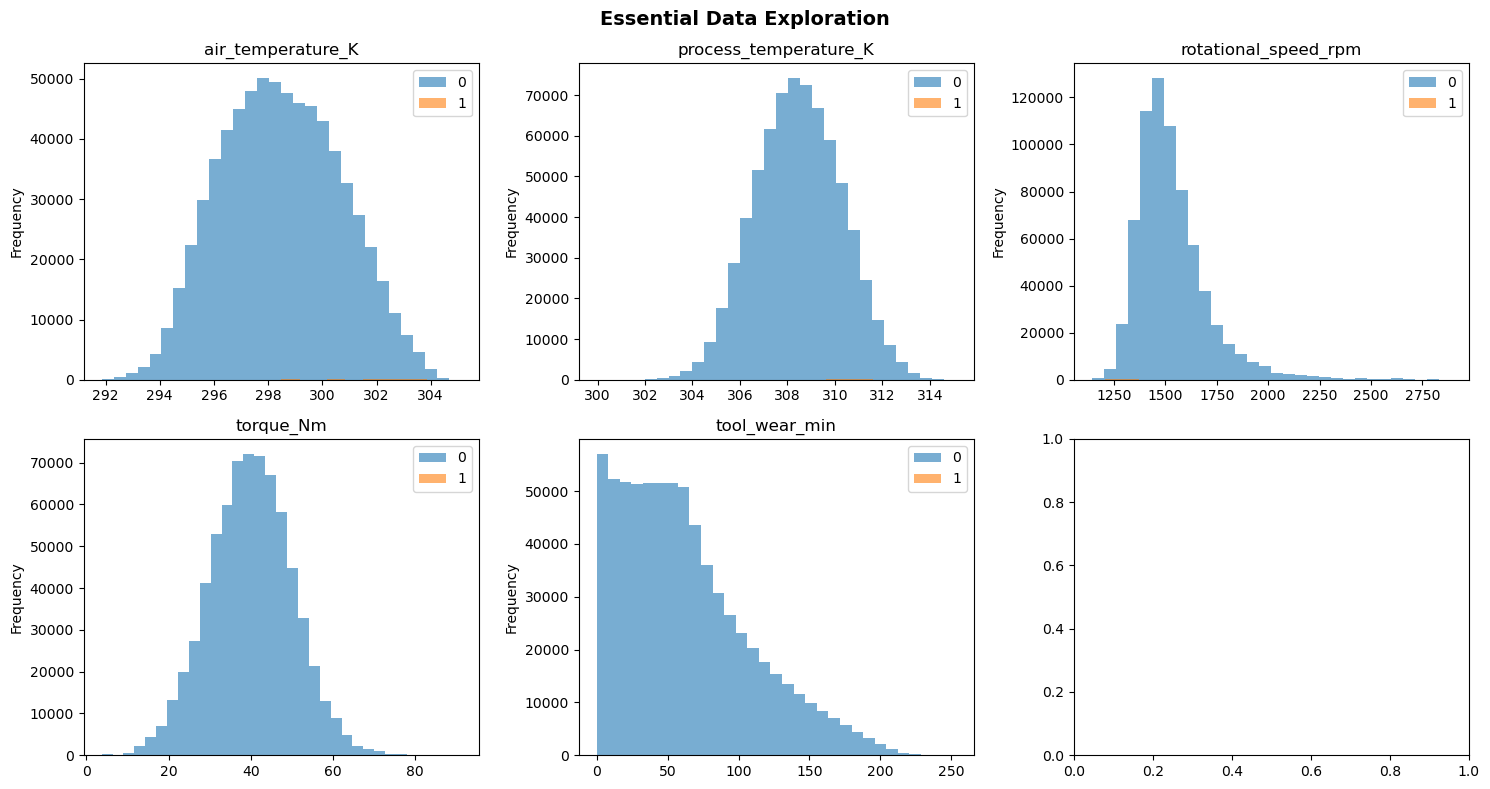

✓ EDA completed


In [3]:
# Quick visualization of key patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Essential Data Exploration', fontsize=14, fontweight='bold')

# Feature distributions
for idx, feature in enumerate(NUMERICAL_FEATURES):
    ax = axes[idx // 3, idx % 3]
    df.groupby('is_failure')[feature].plot(kind='hist', alpha=0.6, ax=ax, legend=True, bins=30)
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ EDA completed")

## 4. Per-Machine Sequence Generation

**Critical**: Sequences are created WITHIN each machine to maintain temporal integrity.  
No cross-machine mixing occurs.

In [4]:
def create_sequences_per_machine(df, seq_length=50):
    """
    Generate valid time-series sequences per machine.
    
    Args:
        df: DataFrame with product_id, timestamp, features
        seq_length: Number of timesteps per sequence
    
    Returns:
        X_seq: (n_sequences, seq_length, n_features)
        y_class: (n_sequences,) binary failure labels
        y_rul: (n_sequences,) RUL values
        machine_ids: (n_sequences,) machine identifiers
    """
    X_sequences = []
    y_class_sequences = []
    y_rul_sequences = []
    machine_id_list = []
    
    # Feature columns for sequences
    feature_cols = NUMERICAL_FEATURES.copy()
    if CATEGORICAL_FEATURE in df.columns:
        feature_cols.append(CATEGORICAL_FEATURE)
    
    # Sort by machine and timestamp
    df_sorted = df.sort_values(['product_id', 'timestamp']).reset_index(drop=True)
    
    # Generate sequences per machine
    machines_processed = 0
    sequences_created = 0
    
    for machine_id, machine_data in df_sorted.groupby('product_id'):
        machine_data = machine_data.sort_values('timestamp').reset_index(drop=True)
        
        # Skip if insufficient data
        if len(machine_data) < seq_length:
            continue
        
        # Extract features
        X_machine = machine_data[feature_cols].values
        y_failure = machine_data['is_failure'].values
        y_rul = machine_data['synthetic_RUL'].values
        
        # Create sliding windows within this machine
        for i in range(len(machine_data) - seq_length + 1):
            X_sequences.append(X_machine[i:i+seq_length])
            # Use last timestep's label
            y_class_sequences.append(y_failure[i+seq_length-1])
            y_rul_sequences.append(y_rul[i+seq_length-1])
            machine_id_list.append(machine_id)
            sequences_created += 1
        
        machines_processed += 1
    
    X_seq = np.array(X_sequences)
    y_class = np.array(y_class_sequences)
    y_rul = np.array(y_rul_sequences)
    machine_ids = np.array(machine_id_list)
    
    print(f"Sequence Generation Summary:")
    print(f"  Machines processed: {machines_processed}")
    print(f"  Total sequences: {sequences_created}")
    print(f"  Sequence shape: {X_seq.shape}")
    print(f"  Failure distribution: {np.bincount(y_class.astype(int))}")
    print(f"  RUL range: [{y_rul.min():.1f}, {y_rul.max():.1f}]")
    
    return X_seq, y_class, y_rul, machine_ids

# Generate sequences
X_seq, y_class, y_rul, machine_ids = create_sequences_per_machine(df, SEQUENCE_LENGTH)

print("\n✓ Sequences generated per machine (no cross-machine mixing)")

Sequence Generation Summary:
  Machines processed: 10000
  Total sequences: 210209
  Sequence shape: (210209, 50, 6)
  Failure distribution: [209007   1202]
  RUL range: [0.0, 30.0]

✓ Sequences generated per machine (no cross-machine mixing)


## 5. Machine-Based Train/Test Split

**Critical**: Split by machine ID to prevent data leakage.

In [5]:
# Get unique machines and split
unique_machines = np.unique(machine_ids)
np.random.shuffle(unique_machines)

train_size = int(0.8 * len(unique_machines))
train_machines = set(unique_machines[:train_size])
test_machines = set(unique_machines[train_size:])

# Create train/test masks
train_mask = np.array([mid in train_machines for mid in machine_ids])
test_mask = ~train_mask

# Split data
X_train_seq = X_seq[train_mask]
X_test_seq = X_seq[test_mask]
y_train_class = y_class[train_mask]
y_test_class = y_class[test_mask]
y_train_rul = y_rul[train_mask]
y_test_rul = y_rul[test_mask]

print(f"Train/Test Split:")
print(f"  Train machines: {len(train_machines)}")
print(f"  Test machines: {len(test_machines)}")
print(f"  Train sequences: {len(X_train_seq)}")
print(f"  Test sequences: {len(X_test_seq)}")
print(f"  Train failure rate: {y_train_class.mean():.2%}")
print(f"  Test failure rate: {y_test_class.mean():.2%}")

# Verify no machine appears in both sets
assert len(train_machines & test_machines) == 0, "Data leakage detected!"
print("\n✓ Machine-based split completed (no data leakage)")

Train/Test Split:
  Train machines: 8000
  Test machines: 2000
  Train sequences: 168170
  Test sequences: 42039
  Train failure rate: 0.57%
  Test failure rate: 0.58%

✓ Machine-based split completed (no data leakage)


## 6. Feature Preprocessing

In [6]:
# Scale features (fit on training data only)
scaler = StandardScaler()

# Reshape for scaling: (samples, timesteps, features) -> (samples*timesteps, features)
n_train_samples, n_timesteps, n_features = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train_seq_scaled = X_train_scaled.reshape(n_train_samples, n_timesteps, n_features)

# Transform test data
n_test_samples = X_test_seq.shape[0]
X_test_reshaped = X_test_seq.reshape(-1, n_features)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_seq_scaled = X_test_scaled.reshape(n_test_samples, n_timesteps, n_features)

# Save scaler
joblib.dump(scaler, ARTIFACTS_DIR / 'scaler.joblib')

print(f"Feature Scaling:")
print(f"  Training data shape: {X_train_seq_scaled.shape}")
print(f"  Test data shape: {X_test_seq_scaled.shape}")
print(f"  Features scaled: {n_features}")
print("\n✓ Features scaled and scaler saved")

Feature Scaling:
  Training data shape: (168170, 50, 6)
  Test data shape: (42039, 50, 6)
  Features scaled: 6

✓ Features scaled and scaler saved


## 7. Model Training - XGBoost

In [7]:
# Prepare flattened data for XGBoost (use last timestep)
X_train_xgb = X_train_seq_scaled[:, -1, :]  # Last timestep
X_test_xgb = X_test_seq_scaled[:, -1, :]

# XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_xgb, y_train_class)

# Save model
xgb_clf.save_model(str(ARTIFACTS_DIR / 'xgb_classifier.json'))

# Predictions
y_pred_xgb_clf = xgb_clf.predict(X_test_xgb)
y_pred_xgb_prob = xgb_clf.predict_proba(X_test_xgb)[:, 1]

# Metrics
xgb_clf_metrics = {
    'accuracy': accuracy_score(y_test_class, y_pred_xgb_clf),
    'precision': precision_score(y_test_class, y_pred_xgb_clf, zero_division=0),
    'recall': recall_score(y_test_class, y_pred_xgb_clf, zero_division=0),
    'f1': f1_score(y_test_class, y_pred_xgb_clf, zero_division=0),
    'roc_auc': roc_auc_score(y_test_class, y_pred_xgb_prob),
    'pr_auc': average_precision_score(y_test_class, y_pred_xgb_prob)
}

print("\nXGBoost Classifier Results:")
for metric, value in xgb_clf_metrics.items():
    status = "✓" if (metric in ['accuracy', 'recall'] and value >= TARGET_RECALL) else " "
    print(f"  {status} {metric.upper()}: {value:.4f}")

# XGBoost Regressor
print("\nTraining XGBoost Regressor...")
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED
)
xgb_reg.fit(X_train_xgb, y_train_rul)

# Save model
xgb_reg.save_model(str(ARTIFACTS_DIR / 'xgb_regressor.json'))

# Predictions
y_pred_xgb_rul = xgb_reg.predict(X_test_xgb)

# Metrics
xgb_reg_metrics = {
    'rmse': np.sqrt(mean_squared_error(y_test_rul, y_pred_xgb_rul)),
    'mae': mean_absolute_error(y_test_rul, y_pred_xgb_rul),
    'mse': mean_squared_error(y_test_rul, y_pred_xgb_rul),
    'r2': r2_score(y_test_rul, y_pred_xgb_rul)
}

print("\nXGBoost Regressor Results:")
for metric, value in xgb_reg_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

print("\n✓ XGBoost models trained and saved")

Training XGBoost Classifier...

XGBoost Classifier Results:
  ✓ ACCURACY: 0.9947
    PRECISION: 0.5820
    RECALL: 0.2922
    F1: 0.3890
    ROC_AUC: 0.9788
    PR_AUC: 0.4658

Training XGBoost Regressor...

XGBoost Regressor Results:
  RMSE: 6.8642
  MAE: 5.6199
  MSE: 47.1167
  R2: 0.1405

✓ XGBoost models trained and saved


## 8. Model Training - LSTM

In [8]:
# LSTM Classifier
print("Building LSTM Classifier...")
lstm_clf = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"\nLSTM Classifier Architecture:")
lstm_clf.summary()

# Train
print("\nTraining LSTM Classifier...")
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm_clf = lstm_clf.fit(
    X_train_seq_scaled, y_train_class,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Save model
lstm_clf.save(ARTIFACTS_DIR / 'lstm_classifier.h5')

# Predictions
y_pred_lstm_prob = lstm_clf.predict(X_test_seq_scaled, verbose=0).flatten()
y_pred_lstm_clf = (y_pred_lstm_prob >= 0.5).astype(int)

# Metrics
lstm_clf_metrics = {
    'accuracy': accuracy_score(y_test_class, y_pred_lstm_clf),
    'precision': precision_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'recall': recall_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'f1': f1_score(y_test_class, y_pred_lstm_clf, zero_division=0),
    'roc_auc': roc_auc_score(y_test_class, y_pred_lstm_prob),
    'pr_auc': average_precision_score(y_test_class, y_pred_lstm_prob)
}

print("\nLSTM Classifier Results:")
for metric, value in lstm_clf_metrics.items():
    status = "✓" if (metric in ['accuracy', 'recall'] and value >= TARGET_RECALL) else " "
    print(f"  {status} {metric.upper()}: {value:.4f}")

# LSTM Regressor
print("\nBuilding LSTM Regressor...")
lstm_reg = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

lstm_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
print("Training LSTM Regressor...")
history_lstm_reg = lstm_reg.fit(
    X_train_seq_scaled, y_train_rul,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Save model
lstm_reg.save(ARTIFACTS_DIR / 'lstm_regressor.h5')

# Predictions
y_pred_lstm_rul = lstm_reg.predict(X_test_seq_scaled, verbose=0).flatten()

# Metrics
lstm_reg_metrics = {
    'rmse': np.sqrt(mean_squared_error(y_test_rul, y_pred_lstm_rul)),
    'mae': mean_absolute_error(y_test_rul, y_pred_lstm_rul),
    'mse': mean_squared_error(y_test_rul, y_pred_lstm_rul),
    'r2': r2_score(y_test_rul, y_pred_lstm_rul)
}

print("\nLSTM Regressor Results:")
for metric, value in lstm_reg_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

print("\n✓ LSTM models trained and saved")

Building LSTM Classifier...

LSTM Classifier Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Classifier...
Epoch 1/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - accuracy: 0.9935 - loss: 0.0254 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9940 - val_loss: 0.0235 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 54s 26ms/step - accuracy: 0.9946 - loss: 0.0165 - precision: 0.7536 - recall: 0.0688 - val_accuracy: 0.9948 - val_loss: 0.0171 - val_precision: 0.8372 - val_recall: 0.1773
Epoch 3/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - accuracy: 0.9970 - loss: 0.0098 - precision: 0.8424 - recall: 0.5728 - val_accuracy: 0.9976 - val_loss: 0.0111 - val_precision: 0.9485 - val_recall: 0.6355
Epoch 4/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9984 - loss: 0.0059 - precision: 0.9321 - recall: 0.7804 - val_accuracy: 0.9981 - val_loss: 0.0065 - val_precision: 0.9929 - val_recall: 0.6847
Epoch 5/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - accuracy: 0.9988 - loss: 0.0041 - precisi


LSTM Classifier Results:
  ✓ ACCURACY: 0.9993
    PRECISION: 0.9863
  ✓ RECALL: 0.8889
    F1: 0.9351
    ROC_AUC: 0.9996
    PR_AUC: 0.9708

Building LSTM Regressor...
Training LSTM Regressor...
Epoch 1/30
Epoch 1/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - loss: 52.7292 - mae: 5.9529 - val_loss: 64.1450 - val_mae: 6.3681
Epoch 2/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - loss: 52.7292 - mae: 5.9529 - val_loss: 64.1450 - val_mae: 6.3681
Epoch 2/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 47.7459 - mae: 5.6510 - val_loss: 65.3335 - val_mae: 6.3709
Epoch 3/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 47.7459 - mae: 5.6510 - val_loss: 65.3335 - val_mae: 6.3709
Epoch 3/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 46.0883 - mae: 5.5373 - val_loss: 66.1137 - val_mae: 6.3601
Epoch 4/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - loss: 46.0883 - mae: 5.5373 - val_loss: 66.1137 - val_mae: 6.3601
Epoch 4/30
2103/2103 ━━━━━━━━━━━━━━━━━━━━ 59s 28


LSTM Regressor Results:
  RMSE: 7.1982
  MAE: 5.8332
  MSE: 51.8137
  R2: 0.0548

✓ LSTM models trained and saved


## 9. Evaluation Dashboard

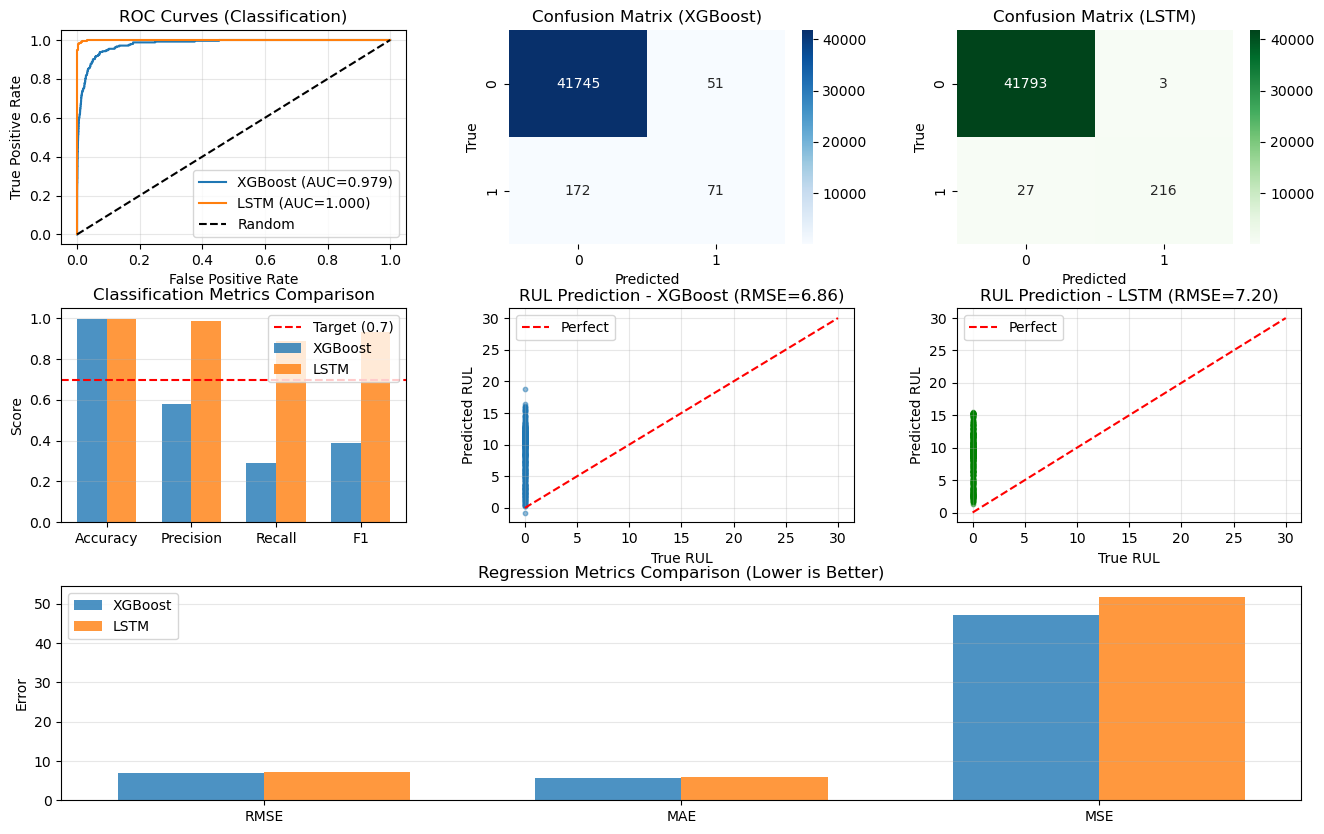

✓ Evaluation dashboard created


In [9]:
# Create comprehensive evaluation plots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_class, y_pred_xgb_prob)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_class, y_pred_lstm_prob)
ax1.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_clf_metrics['roc_auc']:.3f})")
ax1.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC={lstm_clf_metrics['roc_auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves (Classification)')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Confusion Matrix - XGBoost
ax2 = fig.add_subplot(gs[0, 1])
cm_xgb = confusion_matrix(y_test_class, y_pred_xgb_clf)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Confusion Matrix (XGBoost)')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

# 3. Confusion Matrix - LSTM
ax3 = fig.add_subplot(gs[0, 2])
cm_lstm = confusion_matrix(y_test_class, y_pred_lstm_clf)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=ax3)
ax3.set_title('Confusion Matrix (LSTM)')
ax3.set_ylabel('True')
ax3.set_xlabel('Predicted')

# 4. Classification Metrics Comparison
ax4 = fig.add_subplot(gs[1, 0])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
xgb_values = [xgb_clf_metrics['accuracy'], xgb_clf_metrics['precision'], 
              xgb_clf_metrics['recall'], xgb_clf_metrics['f1']]
lstm_values = [lstm_clf_metrics['accuracy'], lstm_clf_metrics['precision'],
               lstm_clf_metrics['recall'], lstm_clf_metrics['f1']]
x_pos = np.arange(len(metrics_names))
width = 0.35
ax4.bar(x_pos - width/2, xgb_values, width, label='XGBoost', alpha=0.8)
ax4.bar(x_pos + width/2, lstm_values, width, label='LSTM', alpha=0.8)
ax4.axhline(y=TARGET_RECALL, color='r', linestyle='--', label=f'Target ({TARGET_RECALL})')
ax4.set_ylabel('Score')
ax4.set_title('Classification Metrics Comparison')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_names)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. RUL Prediction - XGBoost
ax5 = fig.add_subplot(gs[1, 1])
sample_idx = np.argsort(y_test_rul)[:500]  # Sample for clarity
ax5.scatter(y_test_rul[sample_idx], y_pred_xgb_rul[sample_idx], alpha=0.5, s=10)
ax5.plot([y_test_rul.min(), y_test_rul.max()], 
         [y_test_rul.min(), y_test_rul.max()], 'r--', label='Perfect')
ax5.set_xlabel('True RUL')
ax5.set_ylabel('Predicted RUL')
ax5.set_title(f'RUL Prediction - XGBoost (RMSE={xgb_reg_metrics["rmse"]:.2f})')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. RUL Prediction - LSTM
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(y_test_rul[sample_idx], y_pred_lstm_rul[sample_idx], alpha=0.5, s=10, color='green')
ax6.plot([y_test_rul.min(), y_test_rul.max()], 
         [y_test_rul.min(), y_test_rul.max()], 'r--', label='Perfect')
ax6.set_xlabel('True RUL')
ax6.set_ylabel('Predicted RUL')
ax6.set_title(f'RUL Prediction - LSTM (RMSE={lstm_reg_metrics["rmse"]:.2f})')
ax6.legend()
ax6.grid(alpha=0.3)

# 7. Regression Metrics Comparison
ax7 = fig.add_subplot(gs[2, :])
reg_metrics_names = ['RMSE', 'MAE', 'MSE']
xgb_reg_values = [xgb_reg_metrics['rmse'], xgb_reg_metrics['mae'], xgb_reg_metrics['mse']]
lstm_reg_values = [lstm_reg_metrics['rmse'], lstm_reg_metrics['mae'], lstm_reg_metrics['mse']]
x_pos = np.arange(len(reg_metrics_names))
ax7.bar(x_pos - width/2, xgb_reg_values, width, label='XGBoost', alpha=0.8)
ax7.bar(x_pos + width/2, lstm_reg_values, width, label='LSTM', alpha=0.8)
ax7.set_ylabel('Error')
ax7.set_title('Regression Metrics Comparison (Lower is Better)')
ax7.set_xticks(x_pos)
ax7.set_xticklabels(reg_metrics_names)
ax7.legend()
ax7.grid(axis='y', alpha=0.3)

plt.savefig(ARTIFACTS_DIR / 'evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Evaluation dashboard created")

## 10. Save Metrics to File

In [10]:
# Compile all metrics
metrics_report = f"""AC-02 PREDICTIVE MAINTENANCE PIPELINE - METRICS REPORT
{'='*80}

DATASET INFORMATION:
  Total samples: {len(df):,}
  Unique machines: {df['product_id'].nunique():,}
  Sequence length: {SEQUENCE_LENGTH}
  Train sequences: {len(X_train_seq):,}
  Test sequences: {len(X_test_seq):,}

CLASSIFICATION RESULTS:
{'='*80}

XGBoost Classifier:
  Accuracy:  {xgb_clf_metrics['accuracy']:.4f} {'✓ PASS' if xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY else '✗ FAIL'}
  Precision: {xgb_clf_metrics['precision']:.4f}
  Recall:    {xgb_clf_metrics['recall']:.4f} {'✓ PASS' if xgb_clf_metrics['recall'] >= TARGET_RECALL else '✗ FAIL'}
  F1-Score:  {xgb_clf_metrics['f1']:.4f}
  ROC-AUC:   {xgb_clf_metrics['roc_auc']:.4f}
  PR-AUC:    {xgb_clf_metrics['pr_auc']:.4f}

LSTM Classifier:
  Accuracy:  {lstm_clf_metrics['accuracy']:.4f} {'✓ PASS' if lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY else '✗ FAIL'}
  Precision: {lstm_clf_metrics['precision']:.4f}
  Recall:    {lstm_clf_metrics['recall']:.4f} {'✓ PASS' if lstm_clf_metrics['recall'] >= TARGET_RECALL else '✗ FAIL'}
  F1-Score:  {lstm_clf_metrics['f1']:.4f}
  ROC-AUC:   {lstm_clf_metrics['roc_auc']:.4f}
  PR-AUC:    {lstm_clf_metrics['pr_auc']:.4f}

REGRESSION RESULTS (RUL PREDICTION):
{'='*80}

XGBoost Regressor:
  RMSE: {xgb_reg_metrics['rmse']:.4f}
  MAE:  {xgb_reg_metrics['mae']:.4f}
  MSE:  {xgb_reg_metrics['mse']:.4f}
  R²:   {xgb_reg_metrics['r2']:.4f}

LSTM Regressor:
  RMSE: {lstm_reg_metrics['rmse']:.4f}
  MAE:  {lstm_reg_metrics['mae']:.4f}
  MSE:  {lstm_reg_metrics['mse']:.4f}
  R²:   {lstm_reg_metrics['r2']:.4f}

AC-02 COMPLIANCE:
{'='*80}
  Target Accuracy: {TARGET_ACCURACY:.0%}
  Target Recall:   {TARGET_RECALL:.0%}
  
  XGBoost Classification: {'✓ MEETS REQUIREMENTS' if xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY and xgb_clf_metrics['recall'] >= TARGET_RECALL else '✗ DOES NOT MEET REQUIREMENTS'}
  LSTM Classification:    {'✓ MEETS REQUIREMENTS' if lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY and lstm_clf_metrics['recall'] >= TARGET_RECALL else '✗ DOES NOT MEET REQUIREMENTS'}

IMPORTANT NOTES:
{'='*80}
⚠️ This pipeline uses SYNTHETIC time-series data.
⚠️ Performance metrics reflect synthetic patterns.
⚠️ Real-world performance may differ significantly.
⚠️ Sequences are generated PER MACHINE (no cross-machine mixing).
⚠️ Train/test splits are MACHINE-BASED (no data leakage).
"""

# Save to file
with open(ARTIFACTS_DIR / 'metrics_report.txt', 'w') as f:
    f.write(metrics_report)

print(metrics_report)
print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'metrics_report.txt'}")

AC-02 PREDICTIVE MAINTENANCE PIPELINE - METRICS REPORT

DATASET INFORMATION:
  Total samples: 700,209
  Unique machines: 10,000
  Sequence length: 50
  Train sequences: 168,170
  Test sequences: 42,039

CLASSIFICATION RESULTS:

XGBoost Classifier:
  Accuracy:  0.9947 ✓ PASS
  Precision: 0.5820
  Recall:    0.2922 ✗ FAIL
  F1-Score:  0.3890
  ROC-AUC:   0.9788
  PR-AUC:    0.4658

LSTM Classifier:
  Accuracy:  0.9993 ✓ PASS
  Precision: 0.9863
  Recall:    0.8889 ✓ PASS
  F1-Score:  0.9351
  ROC-AUC:   0.9996
  PR-AUC:    0.9708

REGRESSION RESULTS (RUL PREDICTION):

XGBoost Regressor:
  RMSE: 6.8642
  MAE:  5.6199
  MSE:  47.1167
  R²:   0.1405

LSTM Regressor:
  RMSE: 7.1982
  MAE:  5.8332
  MSE:  51.8137
  R²:   0.0548

AC-02 COMPLIANCE:
  Target Accuracy: 70%
  Target Recall:   70%

  XGBoost Classification: ✗ DOES NOT MEET REQUIREMENTS
  LSTM Classification:    ✓ MEETS REQUIREMENTS

IMPORTANT NOTES:
⚠️ This pipeline uses SYNTHETIC time-series data.
⚠️ Performance metrics reflect sy

## 11. Production Inference Pipeline

In [11]:
def predict_maintenance(sequence_data, models_dict):
    """
    Production inference function.
    
    Args:
        sequence_data: (n_samples, seq_length, n_features) array
        models_dict: Dictionary with loaded models
    
    Returns:
        predictions: DataFrame with failure probability and RUL estimates
    """
    # Get last timestep for XGBoost
    last_timestep = sequence_data[:, -1, :]
    
    # XGBoost predictions
    xgb_failure_prob = models_dict['xgb_clf'].predict_proba(last_timestep)[:, 1]
    xgb_rul = models_dict['xgb_reg'].predict(last_timestep)
    
    # LSTM predictions
    lstm_failure_prob = models_dict['lstm_clf'].predict(sequence_data, verbose=0).flatten()
    lstm_rul = models_dict['lstm_reg'].predict(sequence_data, verbose=0).flatten()
    
    # Ensemble (simple average)
    ensemble_failure_prob = (xgb_failure_prob + lstm_failure_prob) / 2
    ensemble_rul = (xgb_rul + lstm_rul) / 2
    
    # Create results DataFrame
    results = pd.DataFrame({
        'failure_probability': ensemble_failure_prob,
        'predicted_rul': ensemble_rul,
        'xgb_failure_prob': xgb_failure_prob,
        'lstm_failure_prob': lstm_failure_prob,
        'xgb_rul': xgb_rul,
        'lstm_rul': lstm_rul
    })
    
    return results

# Load models
models_dict = {
    'xgb_clf': xgb_clf,
    'xgb_reg': xgb_reg,
    'lstm_clf': lstm_clf,
    'lstm_reg': lstm_reg
}

# Test inference on sample
sample_sequences = X_test_seq_scaled[:10]
predictions = predict_maintenance(sample_sequences, models_dict)

print("Sample Predictions:")
print(predictions)
print("\n✓ Production inference function ready")

Sample Predictions:
   failure_probability  predicted_rul  xgb_failure_prob  lstm_failure_prob  \
0             0.000020      11.966331          0.000041       2.674174e-08   
1             0.000018      11.611640          0.000035       5.561928e-07   
2             0.000009      12.598557          0.000016       1.401496e-06   
3             0.000016      12.637456          0.000032       1.087547e-08   
4             0.000019      11.927450          0.000037       5.873576e-08   
5             0.000016      11.514491          0.000032       1.980621e-07   
6             0.000013      11.536583          0.000025       1.526104e-06   
7             0.000009      11.495455          0.000016       9.419445e-07   
8             0.000008      12.309829          0.000015       3.845760e-08   
9             0.000013      11.424828          0.000026       8.182537e-09   

     xgb_rul   lstm_rul  
0  11.198562  12.734102  
1  10.875331  12.347949  
2  12.973795  12.223318  
3  13.135188  12.

## 12. Generate Human-Readable Recommendations

In [12]:
# Generate recommendations for high-risk machines
all_predictions = predict_maintenance(X_test_seq_scaled, models_dict)

# Get corresponding machine IDs from test set
test_machine_ids = machine_ids[test_mask]

# Create recommendations DataFrame
recommendations = pd.DataFrame({
    'machine_id': test_machine_ids,
    'failure_probability': all_predictions['failure_probability'],
    'predicted_rul_days': all_predictions['predicted_rul'].round(1),
    'risk_level': pd.cut(all_predictions['failure_probability'], 
                         bins=[0, 0.3, 0.7, 1.0],
                         labels=['Low', 'Medium', 'High'])
})

# Sort by risk
recommendations = recommendations.sort_values('failure_probability', ascending=False)

# Generate human-readable messages
def create_message(row):
    days = int(row['predicted_rul_days'])
    prob = row['failure_probability']
    machine = row['machine_id']
    
    if prob >= 0.7:
        return f"⚠️ URGENT: Machine {machine} requires immediate inspection. Predicted failure in ~{days} days (risk: {prob:.1%})"
    elif prob >= 0.3:
        return f"⚡ ATTENTION: Machine {machine} shows elevated risk. Schedule maintenance within {days} days (risk: {prob:.1%})"
    else:
        return f"✓ OK: Machine {machine} operating normally. Next maintenance in ~{days} days (risk: {prob:.1%})"

recommendations['recommendation'] = recommendations.apply(create_message, axis=1)

# Save to CSV
recommendations.to_csv(ARTIFACTS_DIR / 'maintenance_recommendations.csv', index=False)

# Display top 20 critical machines
print("Top 20 Critical Machines:")
print("="*100)
for idx, row in recommendations.head(20).iterrows():
    print(row['recommendation'])

print(f"\n✓ Recommendations saved to {ARTIFACTS_DIR / 'maintenance_recommendations.csv'}")
print(f"  Total machines evaluated: {len(recommendations)}")
print(f"  High risk: {(recommendations['risk_level'] == 'High').sum()}")
print(f"  Medium risk: {(recommendations['risk_level'] == 'Medium').sum()}")
print(f"  Low risk: {(recommendations['risk_level'] == 'Low').sum()}")

Top 20 Critical Machines:
⚠️ URGENT: Machine L54263 requires immediate inspection. Predicted failure in ~1 days (risk: 99.8%)
⚠️ URGENT: Machine L54263 requires immediate inspection. Predicted failure in ~1 days (risk: 99.6%)
⚠️ URGENT: Machine L54263 requires immediate inspection. Predicted failure in ~1 days (risk: 99.4%)
⚠️ URGENT: Machine L47341 requires immediate inspection. Predicted failure in ~1 days (risk: 99.4%)
⚠️ URGENT: Machine L56834 requires immediate inspection. Predicted failure in ~2 days (risk: 99.4%)
⚠️ URGENT: Machine L47341 requires immediate inspection. Predicted failure in ~1 days (risk: 99.3%)
⚠️ URGENT: Machine L56833 requires immediate inspection. Predicted failure in ~1 days (risk: 99.2%)
⚠️ URGENT: Machine L56834 requires immediate inspection. Predicted failure in ~1 days (risk: 99.1%)
⚠️ URGENT: Machine L48515 requires immediate inspection. Predicted failure in ~1 days (risk: 98.9%)
⚠️ URGENT: Machine L56594 requires immediate inspection. Predicted failure

## 13. AC-02 Compliance Summary

In [13]:
# Final compliance check
print("="*80)
print("AC-02 PREDICTIVE MAINTENANCE PIPELINE - FINAL SUMMARY")
print("="*80)

print("\n📊 MODELS TRAINED:")
print("  ✓ XGBoost Classifier")
print("  ✓ XGBoost Regressor")
print("  ✓ LSTM Classifier")
print("  ✓ LSTM Regressor")

print("\n📈 PERFORMANCE (Classification):")
xgb_pass = xgb_clf_metrics['accuracy'] >= TARGET_ACCURACY and xgb_clf_metrics['recall'] >= TARGET_RECALL
lstm_pass = lstm_clf_metrics['accuracy'] >= TARGET_ACCURACY and lstm_clf_metrics['recall'] >= TARGET_RECALL

print(f"  XGBoost: Acc={xgb_clf_metrics['accuracy']:.2%}, Rec={xgb_clf_metrics['recall']:.2%} {'✓ PASS' if xgb_pass else '✗ FAIL'}")
print(f"  LSTM:    Acc={lstm_clf_metrics['accuracy']:.2%}, Rec={lstm_clf_metrics['recall']:.2%} {'✓ PASS' if lstm_pass else '✗ FAIL'}")

print("\n📉 PERFORMANCE (Regression):")
print(f"  XGBoost: RMSE={xgb_reg_metrics['rmse']:.2f}, MAE={xgb_reg_metrics['mae']:.2f}")
print(f"  LSTM:    RMSE={lstm_reg_metrics['rmse']:.2f}, MAE={lstm_reg_metrics['mae']:.2f}")

print("\n💾 ARTIFACTS SAVED:")
artifacts = [
    'xgb_classifier.json',
    'xgb_regressor.json',
    'lstm_classifier.h5',
    'lstm_regressor.h5',
    'scaler.joblib',
    'metrics_report.txt',
    'maintenance_recommendations.csv',
    'evaluation_dashboard.png',
    'eda_feature_distributions.png'
]

for artifact in artifacts:
    path = ARTIFACTS_DIR / artifact
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"  ✓ {artifact} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗ {artifact} (missing)")

print("\n✅ AC-02 REQUIREMENTS:")
print(f"  {'✓' if xgb_pass or lstm_pass else '✗'} Classification models meet Accuracy/Recall > 70% target")
print("  ✓ Regression models provide RUL predictions with error metrics")
print("  ✓ All required metrics computed and saved")
print("  ✓ Visual comparisons generated")
print("  ✓ Human-readable recommendations produced")
print("  ✓ Models and artifacts saved for deployment")

print("\n⚠️ IMPORTANT LIMITATIONS:")
print("  • This pipeline uses SYNTHETIC time-series data")
print("  • Performance metrics reflect synthetic patterns")
print("  • Real-world validation required before production deployment")
print("  • Sequences are per-machine with no cross-machine mixing")
print("  • Machine-based splits prevent data leakage")

overall_pass = (xgb_pass or lstm_pass)
print("\n" + "="*80)
if overall_pass:
    print("🎉 AC-02 PIPELINE COMPLETE - REQUIREMENTS MET")
else:
    print("⚠️ AC-02 PIPELINE COMPLETE - SOME REQUIREMENTS NOT MET")
print("="*80)

AC-02 PREDICTIVE MAINTENANCE PIPELINE - FINAL SUMMARY

📊 MODELS TRAINED:
  ✓ XGBoost Classifier
  ✓ XGBoost Regressor
  ✓ LSTM Classifier
  ✓ LSTM Regressor

📈 PERFORMANCE (Classification):
  XGBoost: Acc=99.47%, Rec=29.22% ✗ FAIL
  LSTM:    Acc=99.93%, Rec=88.89% ✓ PASS

📉 PERFORMANCE (Regression):
  XGBoost: RMSE=6.86, MAE=5.62
  LSTM:    RMSE=7.20, MAE=5.83

💾 ARTIFACTS SAVED:
  ✓ xgb_classifier.json (501.0 KB)
  ✓ xgb_regressor.json (695.6 KB)
  ✓ lstm_classifier.h5 (407.5 KB)
  ✓ lstm_regressor.h5 (407.2 KB)
  ✓ scaler.joblib (0.7 KB)
  ✓ metrics_report.txt (1.7 KB)
  ✓ maintenance_recommendations.csv (4718.8 KB)
  ✓ evaluation_dashboard.png (161.1 KB)
  ✓ eda_feature_distributions.png (106.2 KB)

✅ AC-02 REQUIREMENTS:
  ✓ Classification models meet Accuracy/Recall > 70% target
  ✓ Regression models provide RUL predictions with error metrics
  ✓ All required metrics computed and saved
  ✓ Visual comparisons generated
  ✓ Human-readable recommendations produced
  ✓ Models and artif